# Parte 4 - Similaridade de palavras

Testamos a similaridade entre palavras com três modelos e comparamos com as notas humanas:

- modelo estático: spaCy `pt_core_news_lg` (como no notebook *similaridadeEntreTokens* da aula)
- transformer: BERTimbau (`neuralmind/bert-base-portuguese-cased`)
- LLM: Gemini

Usamos dois datasets: o nosso (100 pares da parte 2, anotados pela Luiza e pela Rafaela) e o feito em aula
(80 pares, planilha `dados/dataset_aula.xlsx`).

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import torch
from google import genai
from google.genai import types
from pydantic import BaseModel
from scipy.stats import spearmanr
from transformers import AutoModel, AutoTokenizer, logging

logging.set_verbosity_error()   # esconde os avisos de carregamento do BERT

## Leitura dos datasets

A planilha da aula usa os graus 0, 0.25, 0.5, 0.75 e 1. A nossa escala (parte 2) tem os mesmos cinco graus,
numerados de 1 a 5: 1 nenhuma = 0 nada similar, 2 baixa = 0.25, 3 moderada = 0.5, 4 alta = 0.75 e
5 muito alta = 1 sinônimos. Convertemos as nossas notas para a escala da aula com `(nota - 1) / 4`.

In [2]:
nosso = pd.read_csv("../parte 2/corpus/corpus_similaridade.csv", encoding="utf-8-sig")
nosso = pd.DataFrame({
    "palavra_1": nosso["palavra_1"],
    "palavra_2": nosso["palavra_2"],
    "Luiza": (nosso["nota_1"] - 1) / 4,
    "Rafaela": (nosso["nota_2"] - 1) / 4,
    "humano": (nosso["similaridade_media"] - 1) / 4,
})
print(f"Nosso dataset: {len(nosso)} pares")
nosso.head()

Nosso dataset: 100 pares


,palavra_1,palavra_2,Luiza,Rafaela,humano
0,ferramenta,plataforma,0.50,0.50,0.50
1,criptografia,chamar,0.00,0.00,0.00
2,componente,trabalho,0.00,0.00,0.00
3,protocolo,segurança,0.25,0.25,0.25
4,classe,conjunto,0.50,0.50,0.50


In [3]:
aula = pd.read_excel("dados/dataset_aula.xlsx", sheet_name="AmostraParaAnotar")
aula = aula.dropna(subset=["Termo A"])
aula = pd.DataFrame({
    "palavra_1": aula["Termo A"].str.strip().str.lower(),
    "palavra_2": aula["Termo B"].str.strip().str.lower(),
    "Aluno 1": aula["Aluno 1"], "Aluno 2": aula["Aluno 2"], "Aluno 3": aula["Aluno 3"],
    "humano": aula["Anotação Final"],
})
print(f"Dataset de aula: {len(aula)} pares")
aula.head()

Dataset de aula: 80 pares


,palavra_1,palavra_2,Aluno 1,Aluno 2,Aluno 3,humano
0,compilar,interpretar,0.50,0.00,0.50,0.25
1,executar,rodar,0.75,1.00,1.00,1.00
2,inicializar,instanciar,0.75,0.75,1.00,0.75
3,declarar,definir,1.00,1.00,0.75,1.00
4,atribuir,setar,0.75,0.75,1.00,0.75


Concordância entre as pessoas (Spearman), para servir de referência:

In [4]:
print(f"Nosso dataset - Luiza x Rafaela: {spearmanr(nosso['Luiza'], nosso['Rafaela'])[0]:.2f}")
for a, b in [("Aluno 1", "Aluno 2"), ("Aluno 1", "Aluno 3"), ("Aluno 2", "Aluno 3")]:
    print(f"Dataset de aula - {a} x {b}: {spearmanr(aula[a], aula[b])[0]:.2f}")

Nosso dataset - Luiza x Rafaela: 0.83
Dataset de aula - Aluno 1 x Aluno 2: 0.35
Dataset de aula - Aluno 1 x Aluno 3: 0.40
Dataset de aula - Aluno 2 x Aluno 3: 0.37


## Modelo estático: spaCy

Igual ao notebook da aula: similaridade do cosseno entre os vetores das palavras. Para termos compostos
("banco de dados"), o spaCy usa a média dos vetores das palavras. Palavras que o modelo não conhece ficam com
similaridade 0.

In [5]:
nlp = spacy.load("pt_core_news_lg")


def similaridade_spacy(p1, p2):
    doc1, doc2 = nlp(p1), nlp(p2)
    if doc1.vector_norm == 0 or doc2.vector_norm == 0:
        return 0.0
    return doc1.similarity(doc2)


for dados in (nosso, aula):
    dados["spacy"] = [similaridade_spacy(a, b) for a, b in zip(dados["palavra_1"], dados["palavra_2"])]

palavras_aula = set(aula["palavra_1"]) | set(aula["palavra_2"])
print("Palavras do dataset de aula sem vetor no spaCy:",
      sorted(p for p in palavras_aula if not all(t.has_vector for t in nlp(p))))

Palavras do dataset de aula sem vetor no spaCy: ['comitar', 'deployar', 'desalocar', 'parsear', 'tokenizar']


## Transformer: BERTimbau

Cada palavra entra sozinha no BERT; o vetor dela é a média dos vetores dos seus subtokens na última camada.
A similaridade é o cosseno entre os dois vetores.

In [6]:
tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
bert = AutoModel.from_pretrained("neuralmind/bert-base-portuguese-cased")
bert.eval()


def vetor_bert(palavra):
    with torch.no_grad():
        saida = bert(**tokenizer(palavra, return_tensors="pt")).last_hidden_state
    return saida[0, 1:-1].mean(0).numpy()   # tira os tokens [CLS] e [SEP]


def similaridade_bert(p1, p2):
    v1, v2 = vetor_bert(p1), vetor_bert(p2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


for dados in (nosso, aula):
    dados["bert"] = [similaridade_bert(a, b) for a, b in zip(dados["palavra_1"], dados["palavra_2"])]

## LLM: Gemini

O Gemini recebe os mesmos graus e exemplos da planilha da aula e dá um grau para cada par. Os pares vão em
lotes de 25 por pedido, porque o plano gratuito permite só 20 pedidos por dia em cada modelo.

As respostas ficam salvas em `dados/notas_llm_nosso.csv` e `dados/notas_llm_aula.csv`. Se esses arquivos já
existem, o notebook só lê as notas, sem chamar a API. Para chamar de novo, apague os arquivos e defina a
chave antes de abrir o notebook: `export GEMINI_API_KEY="..."`.

In [7]:
MODELO = "gemini-3.5-flash"
INSTRUCOES = """Você vai avaliar a similaridade de significado entre pares de termos da área de computação.
Avalie cada par separadamente e use apenas um destes graus:
0 = nada similar (ex.: ponteiro / teclado)
0.25 = baixa similaridade (ex.: criptografia / backup)
0.5 = média similaridade (ex.: ajustar / padronizar)
0.75 = alta similaridade (ex.: repositório / diretório)
1 = sinônimos (ex.: executar / rodar)
Responda com uma nota para cada número de par da lista."""


class NotaPar(BaseModel):
    par: int
    grau: float
    justificativa: str


def notas_gemini(pares):
    cliente = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
    notas = []
    for inicio in range(0, len(pares), 25):
        lote = pares[inicio:inicio + 25]
        lista = "\n".join(f"{i}. {a} / {b}" for i, (a, b) in enumerate(lote, 1))
        while True:
            try:
                resposta = cliente.models.generate_content(
                    model=MODELO,
                    contents=lista,
                    config=types.GenerateContentConfig(system_instruction=INSTRUCOES, temperature=0,
                                                       response_mime_type="application/json",
                                                       response_schema=list[NotaPar]),
                )
                break
            except genai.errors.APIError as erro:
                if erro.code not in (429, 503):   # 429 = limite do plano gratuito, 503 = servidor ocupado
                    raise
                print("Gemini ocupado, tentando de novo em 60 s")
                time.sleep(60)
        por_par = {n.par: n for n in resposta.parsed}
        for i, (a, b) in enumerate(lote, 1):
            notas.append({"palavra_1": a, "palavra_2": b, "nota_llm": por_par[i].grau,
                          "justificativa": por_par[i].justificativa, "modelo": MODELO})
        print(f"{inicio + len(lote)}/{len(pares)} pares")
    return pd.DataFrame(notas)


for nome, dados in (("nosso", nosso), ("aula", aula)):
    arquivo = f"dados/notas_llm_{nome}.csv"
    if not os.path.exists(arquivo):
        notas_gemini(list(zip(dados["palavra_1"], dados["palavra_2"]))).to_csv(arquivo, index=False)
    llm = pd.read_csv(arquivo)
    dados["llm"] = dados.merge(llm, on=["palavra_1", "palavra_2"], how="left")["nota_llm"].values
    print(f"{nome}: {dados['llm'].notna().sum()} pares com nota do LLM")

nosso: 100 pares com nota do LLM
aula: 80 pares com nota do LLM


## Comparação com as notas humanas

Usamos a correlação de Spearman, que compara a ordem dos pares. Por isso ela funciona mesmo com escalas
diferentes (cosseno de -1 a 1 e graus de 0 a 1).

In [8]:
modelos = ["spacy", "bert", "llm"]
tabela = pd.DataFrame({
    "Nosso dataset": [spearmanr(nosso[m], nosso["humano"])[0] for m in modelos],
    "Dataset de aula": [spearmanr(aula[m], aula["humano"])[0] for m in modelos],
}, index=["spaCy", "BERTimbau", "Gemini"]).round(2)
tabela.to_csv("resultados/correlacoes.csv")
tabela

,Nosso dataset,Dataset de aula
spaCy,0.30,0.07
BERTimbau,0.23,0.11
Gemini,0.68,0.53


In [9]:
print("Nosso dataset, Spearman com cada anotadora:")
for m in modelos:
    print(f"  {m}: Luiza {spearmanr(nosso[m], nosso['Luiza'])[0]:.2f}, Rafaela {spearmanr(nosso[m], nosso['Rafaela'])[0]:.2f}")
print(f"Gemini com a mesma nota da Luiza: {(nosso['llm'] == nosso['Luiza']).sum()} pares; "
      f"da Rafaela: {(nosso['llm'] == nosso['Rafaela']).sum()} pares")
print(f"Média das notas - nosso: humanos {nosso['humano'].mean():.2f}, Gemini {nosso['llm'].mean():.2f}; "
      f"aula: humanos {aula['humano'].mean():.2f}, Gemini {aula['llm'].mean():.2f}")

Nosso dataset, Spearman com cada anotadora:
  spacy: Luiza 0.33, Rafaela 0.28
  bert: Luiza 0.28, Rafaela 0.21
  llm: Luiza 0.67, Rafaela 0.65
Gemini com a mesma nota da Luiza: 65 pares; da Rafaela: 68 pares
Média das notas - nosso: humanos 0.09, Gemini 0.16; aula: humanos 0.69, Gemini 0.70


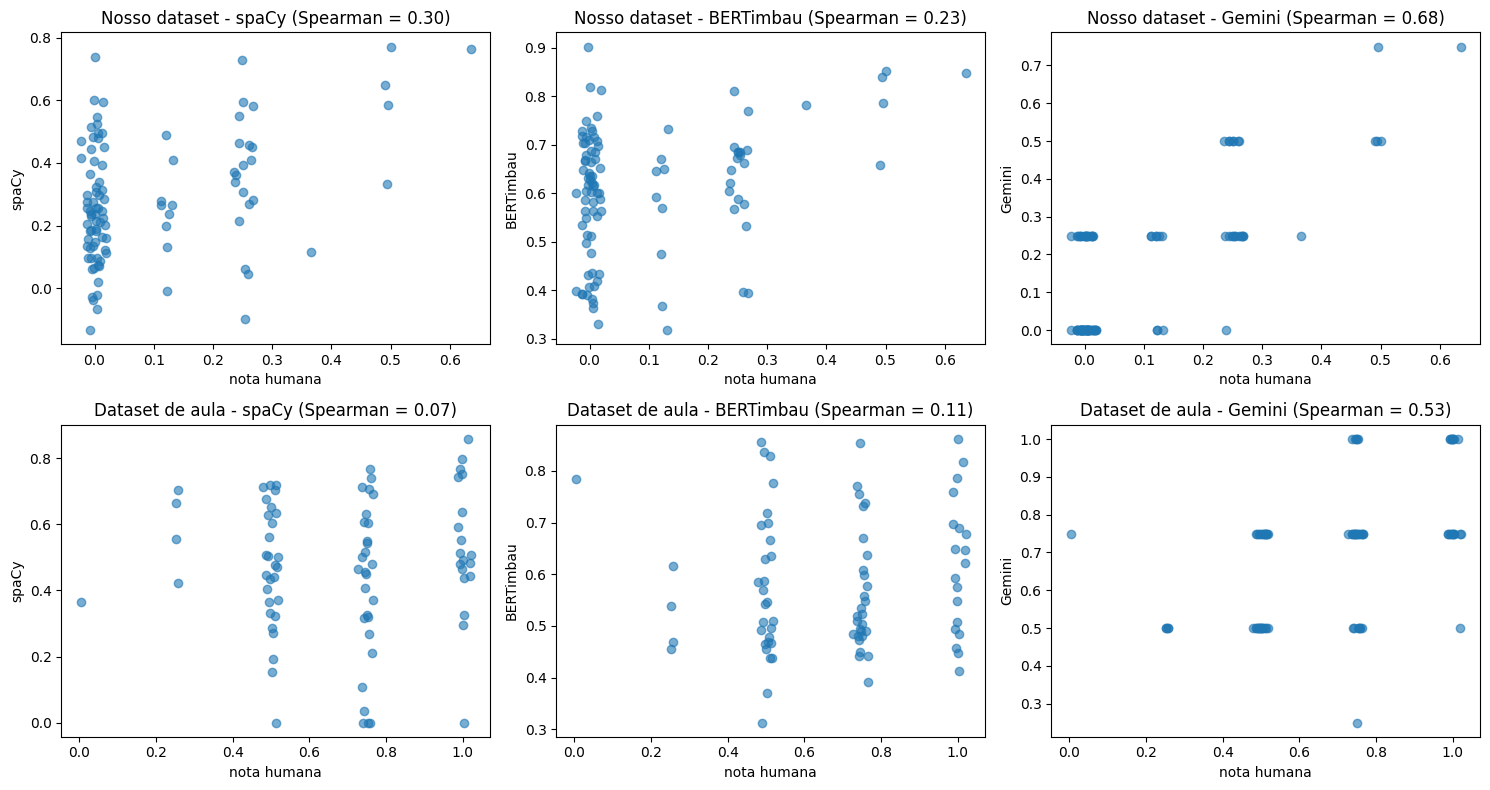

In [10]:
fig, eixos = plt.subplots(2, 3, figsize=(15, 8))
for linha, (nome, dados) in enumerate((("Nosso dataset", nosso), ("Dataset de aula", aula))):
    for ax, m, titulo in zip(eixos[linha], modelos, ["spaCy", "BERTimbau", "Gemini"]):
        tremido = np.random.default_rng(0).normal(0, 0.01, len(dados))   # só para os pontos não se sobreporem
        ax.scatter(dados["humano"] + tremido, dados[m], alpha=0.6)
        ax.set_title(f"{nome} - {titulo} (Spearman = {spearmanr(dados[m], dados['humano'])[0]:.2f})")
        ax.set_xlabel("nota humana")
        ax.set_ylabel(titulo)
plt.tight_layout()
plt.savefig("resultados/dispersao.png", dpi=130)
plt.show()

Pares em que cada modelo mais discorda das pessoas (maior diferença de posição no ranking):

In [11]:
for nome, dados in (("Nosso dataset", nosso), ("Dataset de aula", aula)):
    print(nome)
    for m in modelos:
        diferenca = (dados[m].rank() - dados["humano"].rank()).abs()
        piores = dados.loc[diferenca.sort_values(ascending=False).index[:3]]
        print(f"  {m}: " + "; ".join(f"{r.palavra_1}/{r.palavra_2} ({r[m]:.2f} x {r.humano:.2f})"
                                    for _, r in piores.iterrows()))

Nosso dataset
  spacy: operação/ti (-0.10 x 0.25); tcp/ordem (0.04 x 0.25); chave/dado (0.12 x 0.38)
  bert: descrever/configurar (0.39 x 0.25); tcp/ordem (0.40 x 0.25); pacote/html (0.32 x 0.12)
  llm: ação/registro (0.00 x 0.25); implementar/base (0.00 x 0.12); nome/estrutura (0.00 x 0.12)
Dataset de aula
  spacy: deployar/publicar (0.00 x 1.00); simular/emular (0.70 x 0.25); otimizar/refatorar (0.67 x 0.25)
  bert: vetor/matriz (0.78 x 0.00); deployar/publicar (0.41 x 1.00); kernel/núcleo (0.45 x 1.00)
  llm: conectar/vincular (0.50 x 1.00); vetor/matriz (0.75 x 0.00); serializar/enumerar (0.25 x 0.75)


In [12]:
nosso.to_csv("resultados/similaridades_nosso.csv", index=False)
aula.to_csv("resultados/similaridades_aula.csv", index=False)